## Requirements

Download and instlall: https://github.com/dennisvds/MRS-Digital-Phantom

Make sure to open the notebook in the from the same directory. make a karnel with the same conda environment.

This version of the MRS-Digital-Phantom saves:
a) Raw data (conecntration used for each simulation)
b) updated configueration file for the simulation
c) simulated spectra


Originally created by Dennis van de Sande (https://doi.org/10.1002/mrm.70138)
Modified by Arijit Bhattacharya

# Generate Data

This notebook generates batches of simulated MRS spectra using the MRS phantom framework.
It performs the following steps:

1. Load a configuration file containing simulation parameters.
2. Split the main configuration into individual configurations for each simulation instance.
3. Run simulations for each configuration using the MRS phantom.
4. Save the results (e.g., spectra, ground truth data) for further processing or validation.

> **Note:** Use this notebook when you want to generate a new dataset of simulated MRS spectra in a reproducible and configurable way.


## Imports

In [1]:
# === Library Imports ===
import json                                         # For loading and parsing configuration files
import sys                                          # For system-specific parameters and functions
import torch
from tqdm import tqdm                               # Progress bar for long-running loops
import os                                           # For file and directory operations
from PyQt5.QtWidgets import QApplication            # GUI backend required for voxel selector

# === Set up the project root directory ===
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(PROJECT_ROOT)

# === Local Simulation Core ===
from simulation.mrs_phantom import DigitalPhantom   # Core class for generating phantom-based MRS data
from simulation.run_matlab import MatlabRunner      # Interface to run MATLAB components (if needed)

# === Local GUI Tools ===
from gui.main_voxel_selector import PhantomWindow   # GUI for interactive voxel selection
from gui.defaults import *                          # Default GUI settings (window size, paths, etc.)

# === Local Utility Functions ===
from utils.auxillary import (
    split_config_into_simulations,                  # Break main config into per-simulation configs
    group_simulation_configs_by_settings,           # Group similar configs for efficient processing
    unflatten_dict                                  # Reconstruct nested dictionaries from flattened ones
)
from utils.nii_processing import save_nifti_mrs     # Save MRS data in NIfTI-MRS format

## Settings

In [2]:
# === Load initial configuration ===

# Path to the main configuration file
config_path = './config.json'

# Flag to enable or disable manual voxel selection via GUI
select_voxel = True

# Load the configuration from the JSON file
with open(config_path, 'r') as file:
    config = json.load(file)


## Launch Voxel Selection GUI

In [3]:
# === Optional: Launch voxel selection GUI ===
# Initialize a DigitalPhantom object using the skeleton provided in the config
# This is only needed when GUI-based voxel selection is enabled

if select_voxel:
    phantom = DigitalPhantom(
        skeleton=config['skeleton'],               # Tissue label + anatomical information
        path2metabs=DEFAULT_METAB_DF_PATH,         # Default metabolite database
        path2basis=DEFAULT_path2basis,             # Default basis spectra path
        simulation_params=DEFAULT_SIM_PARAMS,      # Default simulation parameters
    )

    # Initialize Qt application and show the Phantom GUI window
    app = QApplication([])                         # Create an empty QApplication (required for GUI)
    window = PhantomWindow(phantom, config, output_dir='outputs')
    window.show()                                  # Launch the GUI
    app.exec_()                                    # Enter the event loop until the GUI is closed

    # Update the config path with the file generated by the GUI
    config_path = window.config_path


[INFO] 📥 Initializing Digital Phantom...
Metabolites to ignore from basisset: [np.str_('Ref0ppm'), np.str_('Cit'), np.str_('EA'), np.str_('Phenyl'), np.str_('Thr'), np.str_('Ser'), np.str_('Ala'), np.str_('Tyros'), np.str_('EtOH')]
[INFO] 🧬 Generating lipid mask from explicit fat label...
Added voxel: (75, 105, 161, 176, 68, 93) with size (30, 15, 25), size in mm: (30.0, 15.0, 25.0)
Saving selected voxel definitions to new config file...
Saved updated config file to: outputs/simulation_20260217_steu/config.json


# Run Simulations from Config Files
This block runs the batch simulation process. It:

1. Splits the main config into per-voxel simulation configs.
2. Groups those configs by simulation settings (to reuse basis sets).
3. Checks or generates required basis sets.
4. Initializes the DigitalPhantom.
5. Simulates MRS data for each voxel and saves spectra as NIfTI-MRS files.

Saved config outputs/simulation_20260217_steu/simulation_config_0.json
Generated 1 simulation configuration files.
Simulation configurations generated successfully.


Processing settings groups:   0%|                                                                                                                              | 0/1 [00:00<?, ?group/s]


Initializing simulation with settings: (('basis_set_dir', '/home/arijitbhattacharya/MRS-Digital-Phantom/simulation/basissets/MRSCloud-main/basis_save/'), ('basis_set_settings.TE', '30'), ('basis_set_settings.localization', 'PRESS'), ('basis_set_settings.vendor', 'Universal_Seimens'), ('metabs', '[]'), ('path2basis', '/home/arijitbhattacharya/Arijit/Arijit_MRS/BASIS/MRSCloud/LCModel_Siemens_UnEdited_PRESS_30_.BASIS'), ('path2metabs', '/home/arijitbhattacharya/MRS-Digital-Phantom/data/metabolites/metab_df.csv'), ('simulation_params.TR', '2000.0'), ('simulation_params.bandwidth', '2000.0'), ('simulation_params.lipid_amp_factor', '10.0'), ('simulation_params.lipid_lw_max', '50.0'), ('simulation_params.lipid_lw_min', '30.0'), ('simulation_params.lipid_phase_max', '180.0'), ('simulation_params.lipid_phase_min', '-180.0'), ('simulation_params.lipid_sigma', '5.0'), ('simulation_params.mm_json_file', './data/macromolecules/mm_params.json'), ('simulation_params.mm_level', '10.0'), ('simulation_


Simulating voxels for group 0:   0%|                                                                                                                           | 0/1 [00:00<?, ?voxel/s]

⚠️ No B0 map provided, simulating shim imperfections...


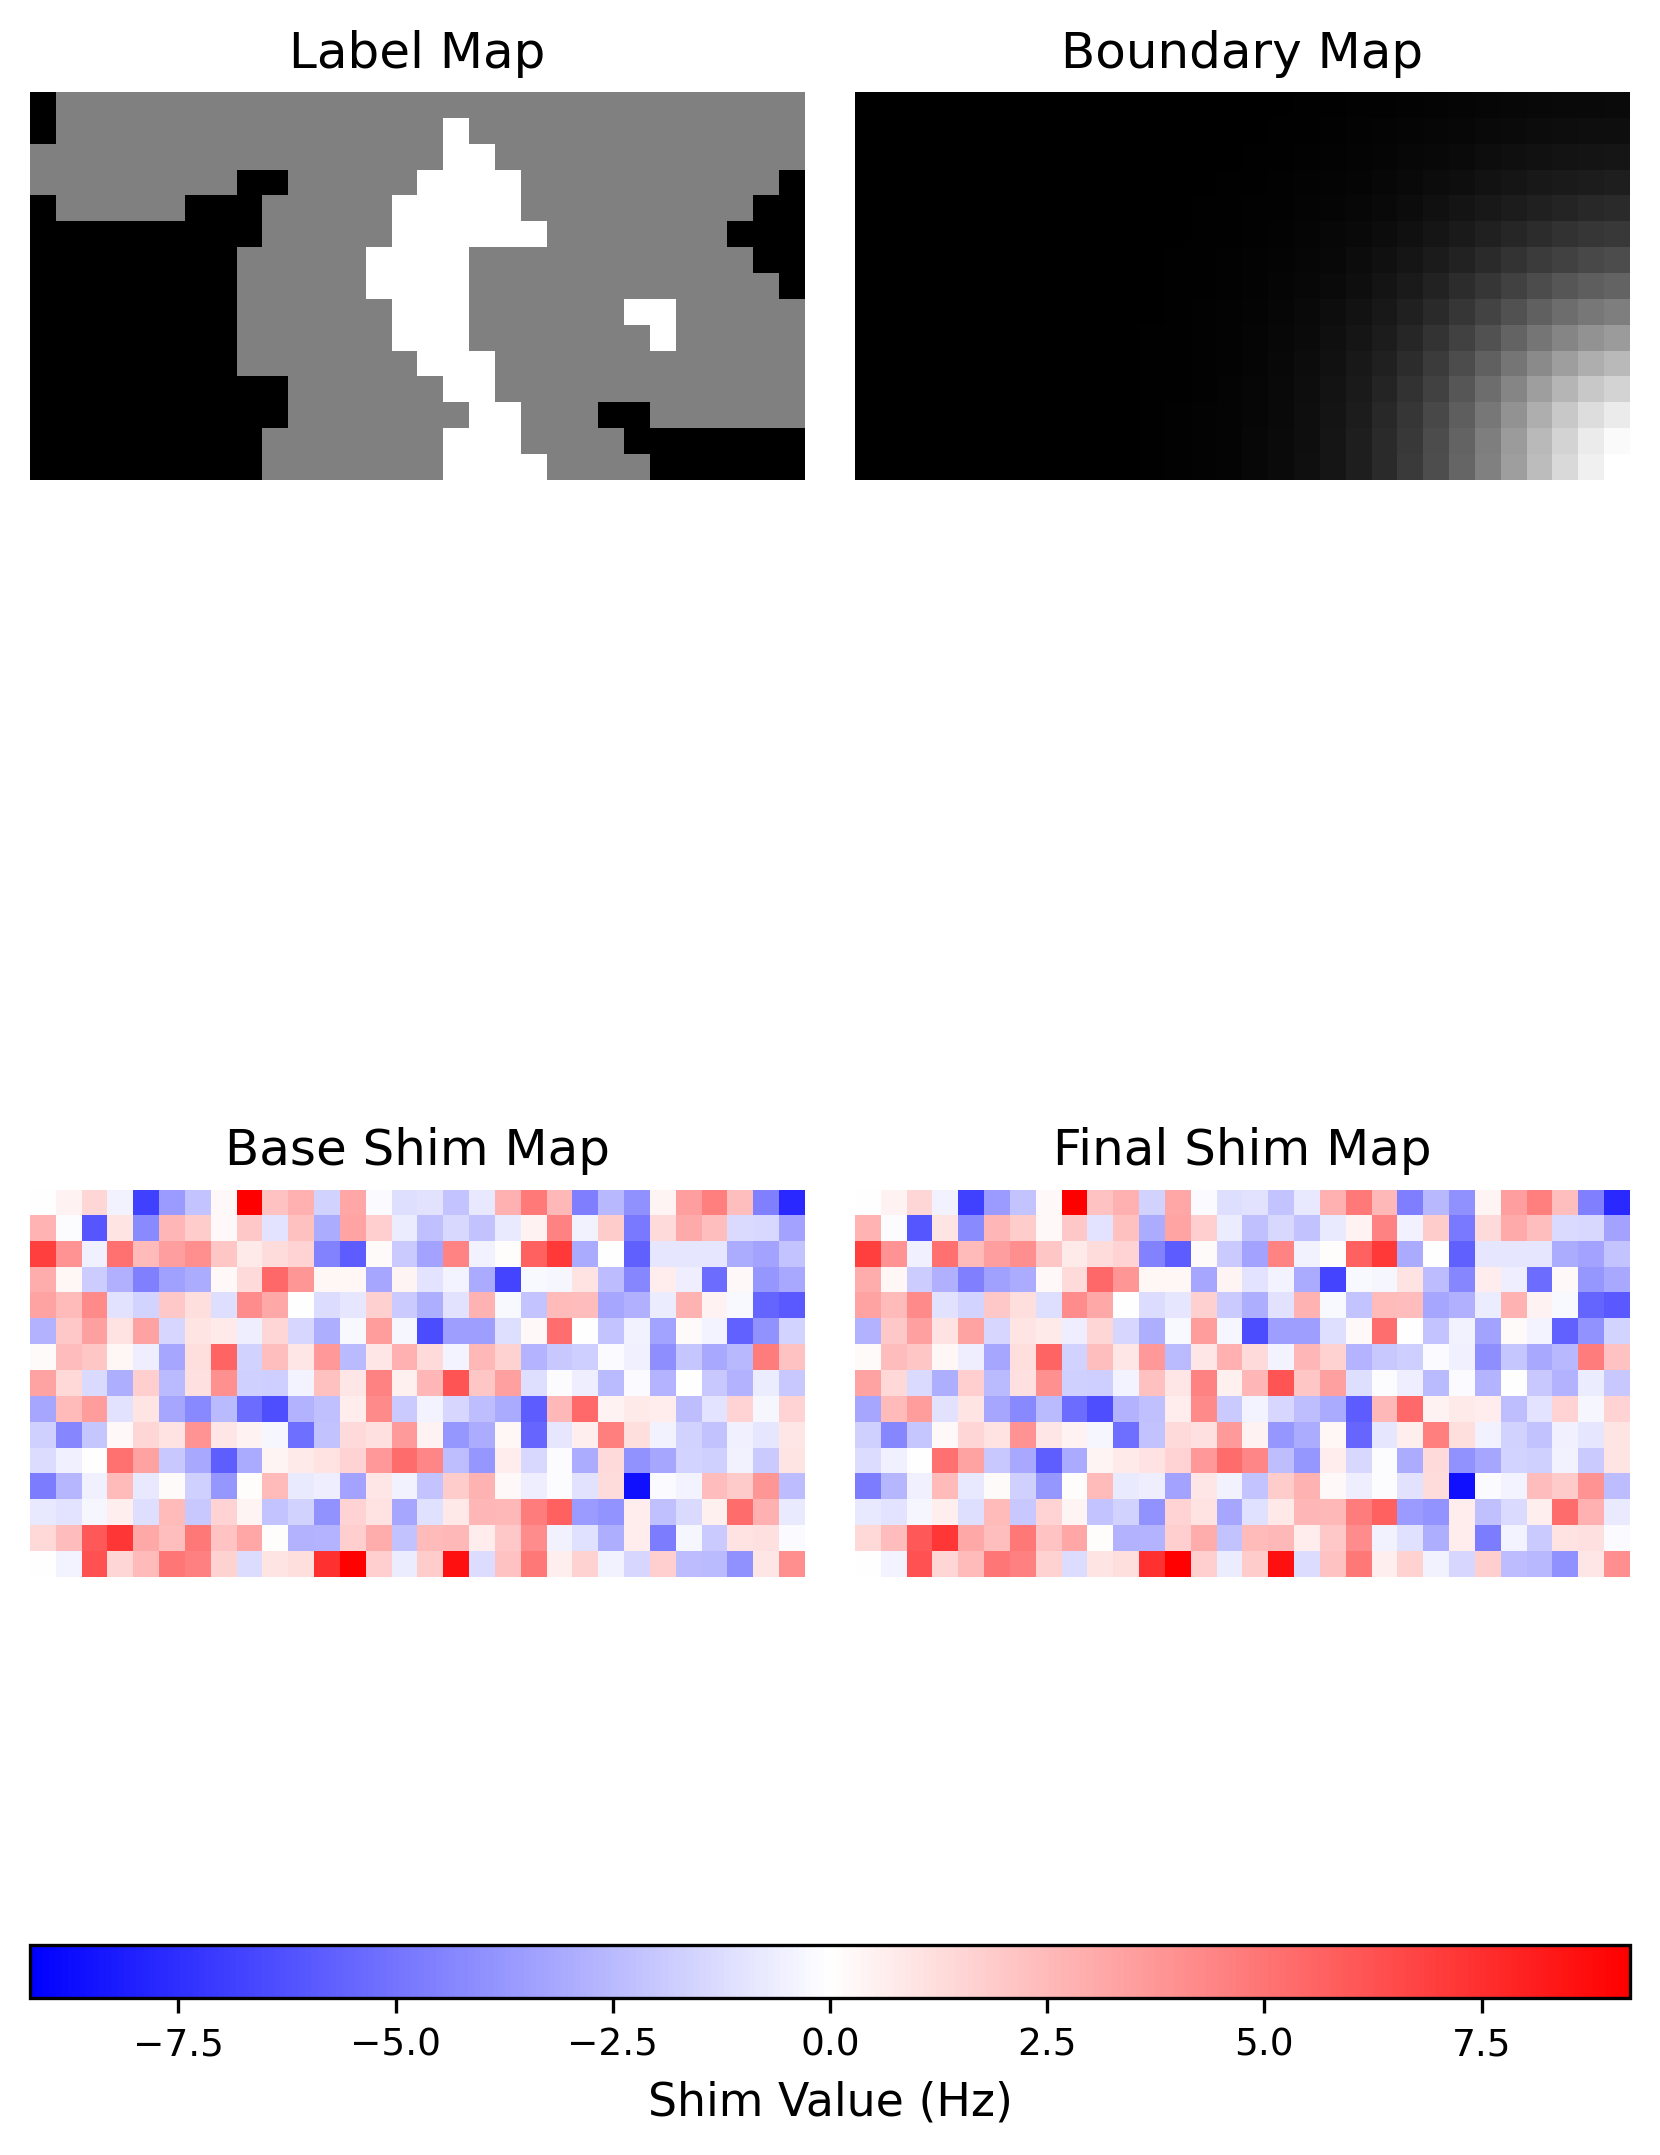

Simulating metabolites...
Removing metabolites from dataframe that are not in the basis set...
3 metabolites removed: {'H2O', 'NAA_Asp', 'Glc'}
Simulating macromolecules...
Simulating lipids...
Loading lipid basis set from cache: ./simulation/lipids/lipids_cache/3a98f2764279d0aa24f0ef564e1de634.mat
Simulating water...
Simulating noise...
✅ Simulation complete!

=== Sampled concentrations per tissue ===
{'Background': {'Asc': 0.0, 'Asp': 0.0, 'Cr': 0.0, 'GABA': 0.0, 'Gln': 0.0, 'Glu': 0.0, 'Gly': 0.0, 'GPC': 0.0, 'GSH': 0.0, 'Lac': 0.0, 'mI': 0.0, 'NAA': 0.0, 'NAAG': 0.0, 'PCh': 0.0, 'PCr': 0.0, 'PE': 0.0, 'sI': 0.0, 'Tau': 0.0}, 'WM': {'Asc': 0.0, 'Asp': 1.5293966069428926, 'Cr': 3.4459434219923777, 'GABA': 1.1824856379790039, 'Gln': 2.5142287642237244, 'Glu': 9.409181763663238, 'Gly': 0.0, 'GPC': 1.26367265405352, 'GSH': 1.2051614118167893, 'Lac': 0.0, 'mI': 5.240780104466008, 'NAA': 9.84268288630311, 'NAAG': 2.2113187707917183, 'PCh': 0.48443032328656777, 'PCr': 2.2560426934211546, '


Processing settings groups: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:13<00:00, 13.11s/group]

Saved spectrum to outputs/simulation_20260217_steu/spectra/water_ref_0
Saved water reference → water_ref_0.nii.gz
Sampled tissue concs: {'Background': {'Asc': 0.0, 'Asp': 0.0, 'Cr': 0.0, 'GABA': 0.0, 'Gln': 0.0, 'Glu': 0.0, 'Gly': 0.0, 'GPC': 0.0, 'GSH': 0.0, 'Lac': 0.0, 'mI': 0.0, 'NAA': 0.0, 'NAAG': 0.0, 'PCh': 0.0, 'PCr': 0.0, 'PE': 0.0, 'sI': 0.0, 'Tau': 0.0}, 'WM': {'Asc': 0.0, 'Asp': 1.5293966069428926, 'Cr': 3.4459434219923777, 'GABA': 1.1824856379790039, 'Gln': 2.5142287642237244, 'Glu': 9.409181763663238, 'Gly': 0.0, 'GPC': 1.26367265405352, 'GSH': 1.2051614118167893, 'Lac': 0.0, 'mI': 5.240780104466008, 'NAA': 9.84268288630311, 'NAAG': 2.2113187707917183, 'PCh': 0.48443032328656777, 'PCr': 2.2560426934211546, 'PE': 0.0, 'sI': 0.6565509449305476, 'Tau': 1.5494626057621135}, 'GM': {'Asc': 1.3361312065226578, 'Asp': 2.499901752273626, 'Cr': 4.591903578308508, 'GABA': 1.8564776703408952, 'Gln': 2.275472847196435, 'Glu': 8.493763871556766, 'Gly': 3.286946940822828, 'GPC': 0.624419

In [4]:
# === Step 1: Split main config into individual simulation configs ===
split_config_into_simulations(config_path)
print("Simulation configurations generated successfully.")

# === Step 2: Group configs by shared simulation/basis settings ===
groups = group_simulation_configs_by_settings(config_path)

idx = 0  # Spectrum index counter for naming
# === Step 3: Loop over each group of settings ===
for settings_key, config_files in tqdm(groups.items(), desc="Processing settings groups", unit="group"):
    
    settings = unflatten_dict(settings_key)
    print(f"\nInitializing simulation with settings: {settings_key}")

    # === Step 4: Determine basis set path ===
    if 'path2basis' in settings:
        # Use provided basis set path
        basis_path = settings['path2basis']
        
        if os.path.exists(basis_path):
            print(f"Using provided basis set: {basis_path}")
        else:
            print(f"Provided basis set path does not exist: {basis_path}")
            print("Falling back to default basis set generation...")

            # Compose expected basis filename
            expected_file_name = f"LCModel_{settings['basis_set_settings']['vendor']}_UnEdited_" \
                                 f"{settings['basis_set_settings']['localization']}_TE" \
                                 f"{settings['basis_set_settings']['TE']}.BASIS"
            basis_path = os.path.join(settings['basis_set_dir'], expected_file_name)

            if os.path.exists(basis_path):
                print(f"Found fallback basis set: {basis_path}")
            else:
                print(f"Generating basis set: {expected_file_name}")
                matlab_runner = MatlabRunner()
                matlab_runner.generate_basis_set(settings['basis_set_settings'])
                print(f"Basis set generated: {basis_path}")

    else:
        # No basis path provided, generate expected filename and check
        expected_file_name = f"LCModel_{settings['basis_set_settings']['vendor']}_UnEdited_" \
                             f"{settings['basis_set_settings']['localization']}_TE" \
                             f"{settings['basis_set_settings']['TE']}.BASIS"
        basis_path = os.path.join(settings['basis_set_dir'], expected_file_name)

        if os.path.exists(basis_path):
            print(f"Using existing basis set: {basis_path}")
        else:
            print(f"Basis set not found: {basis_path}")
            print("Generating new basis set...")
            matlab_runner = MatlabRunner()
            matlab_runner.generate_basis_set(settings['basis_set_settings'])
            print(f"Basis set generated: {basis_path}")

    # === Step 5: Combine simulation and basis parameters ===
    sim_parms = settings['simulation_params']
    basis_params = settings['basis_set_settings']
    all_params = {**sim_parms, **basis_params}

    # === Step 6: Initialize phantom with current settings ===
    phantom = DigitalPhantom(
        skeleton=settings['skeleton'],
        path2metabs=settings['path2metabs'],
        path2basis=basis_path,
        simulation_params=all_params,
        gui=None,  # GUI not used during batch simulations
        metabs=settings['metabs'],
    )

    # === Step 7: Set save directory ===
    save_dir = os.path.join(os.path.dirname(config_path), 'spectra')
    os.makedirs(save_dir, exist_ok=True)

    # === Step 8: Loop over each voxel config in the group ===
    for file in tqdm(config_files, desc=f"Simulating voxels for group {idx}", unit="voxel", leave=False):
        with open(file, 'r') as f:
            config = json.load(f)

        voi_coords = config['voxel_definitions']['coords']

        # Run the simulation
        spec, components, t, ppm, voi_labels = phantom.simulate_data(voi_coords)
        # ============================================================
        # SAVE UNSUPPRESSED WATER AS NIFTI-MRS (for FSL-MRS quant)
        # ============================================================
        if hasattr(phantom.signal_model, "unsuppressed_water"):

            water_specs = phantom.signal_model.unsuppressed_water
        
            # combine tissue contributions
            voi_labels_flat = voi_labels.reshape(-1, voi_labels.shape[-1]).to(torch.complex64)


            water_spec = torch.matmul(voi_labels_flat, water_specs)
            water_spec = water_spec.view(*voi_labels.shape[:3], -1)

            # apply shim
            water_spec = phantom.signal_model.apply_shim_map(
                water_spec,
                phantom.signal_model.shim_map
            )

            # sum voxel
            water_spec = water_spec.sum((0, 1, 2))
            water_np = water_spec.detach().cpu().numpy()
        
            save_nifti_mrs(
                save_dir,
                total_selection=["Water"],
                individual_selection=["Water"],
                components_data={"Water": water_np},
                affine=phantom.affine,
                dwelltime=phantom.basis_set.dwelltime,
                spec_freq=phantom.basis_set.cf,
                sim_params=config,
                base_name=f"water_ref_{idx}",
            )
        
            print(f"Saved water reference → water_ref_{idx}.nii.gz")


        #  NEW: retrieve sampled metabolite concentrations per tissue 
        # per-tissue sampled concentrations
# NEW: accesses SignalModel storage dictionary containing the randomly sampled metabolite concentrations for each tissue prior to voxel mixing
        sampled = phantom.signal_model.sampled_concs_per_tissue

        #  NEW: retrieve final voxel-weighted metabolite concentrations
        # final voxel-weighted concentrations
# NEW: accesses voxel-averaged metabolite concentrations computed using tissue-fraction–weighted linear mixing after simulation
        voxel_final = phantom.signal_model.final_voxel_concentrations

        # NEW: retrieve tissue fractions inside current voxel
# NEW: stores fractional tissue composition of the simulated voxel used for voxel-weighted concentration calculation
        fractions = phantom.signal_model.voxel_tissue_fractions

        
        print("Sampled tissue concs:", sampled)
        print("Final voxel concs:", voxel_final)
        print("Tissue fractions:", fractions)


        # === Step 9: Save result as NIfTI-MRS file ===
        save_nifti_mrs(
            save_dir,
            total_selection=["Metabs", "MMs", "Lipids", "Water", "Noise"],
            individual_selection=["Metabs", "MMs", "Lipids", "Water", "Noise"],
            components_data=components,
            affine=phantom.affine,
            dwelltime=phantom.basis_set.dwelltime,
            spec_freq=phantom.basis_set.cf,
            sim_params=config,
            base_name=f"simulated_spectrum_{idx}",
        )

        
# NEW: define output path for saving concentration metadata associated with this simulated voxel
        conc_save_path = os.path.join(save_dir, f"concentrations_{idx}.json")
        
        with open(conc_save_path, "w") as f:
            json.dump({
                "sampled_per_tissue": sampled,
                "voxel_weighted": voxel_final, 
                "tissue_fractions": fractions
            }, f, indent=2)
# NEW: save sampled per-tissue concentrations, voxel-weighted concentrations, and tissue fractions to JSON
        idx += 1
        # Clean up temporary config file
        os.remove(file)


print("✅ All simulations completed and spectra saved!")
